Wania Arif

Roll No: 24F-AI-053

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)


In [2]:
df = pd.read_csv("student-por.csv" , sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(649, 33)


In [4]:
print("Dataset information:")
print(df.info())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-nu

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


EDA

In [7]:
print("Statistical summary:")
print(df.describe())

Statistical summary:


              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.568567    1.930663    0.221880   
std      1.218138    1.134552    1.099931    0.748660    0.829510    0.593235   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    1.000000    0.000000   
50%     17.000000    2.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean     3.930663    3.180277    3.184900    1.502311    2.280431    3.536210   
std      0.955717    1.0510

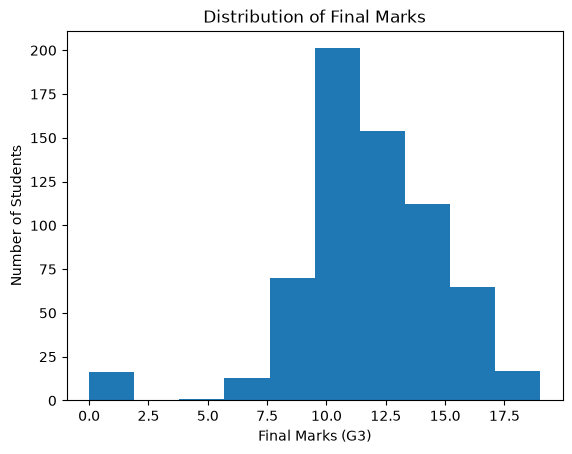

In [8]:
# Distribution of final marks
plt.hist(df["G3"], bins=10)
plt.xlabel("Final Marks (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Marks")
plt.show()

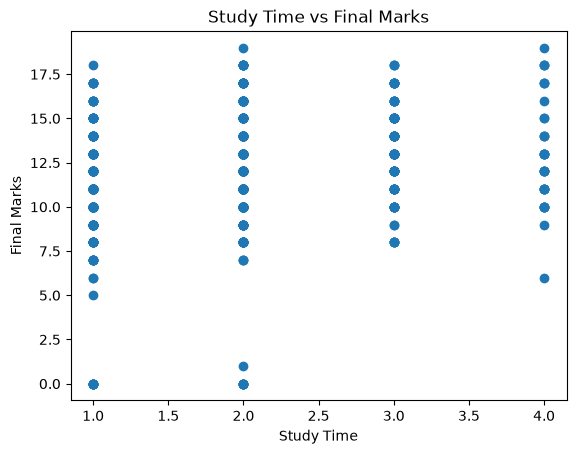

In [9]:
# Study time vs final marks
plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Marks")
plt.title("Study Time vs Final Marks")
plt.show()

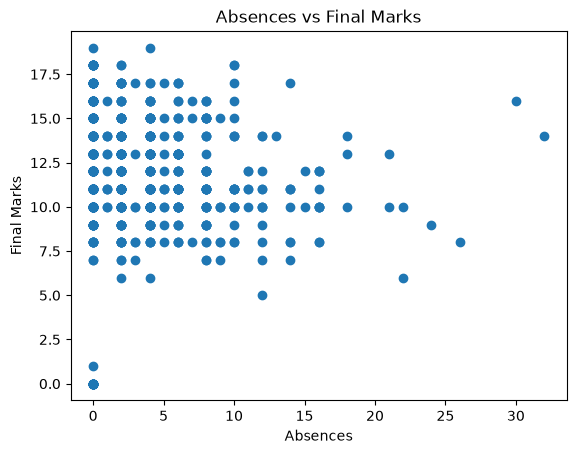

In [10]:
# Attendance/absence vs final marks
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Absences")
plt.ylabel("Final Marks")
plt.title("Absences vs Final Marks")
plt.show()

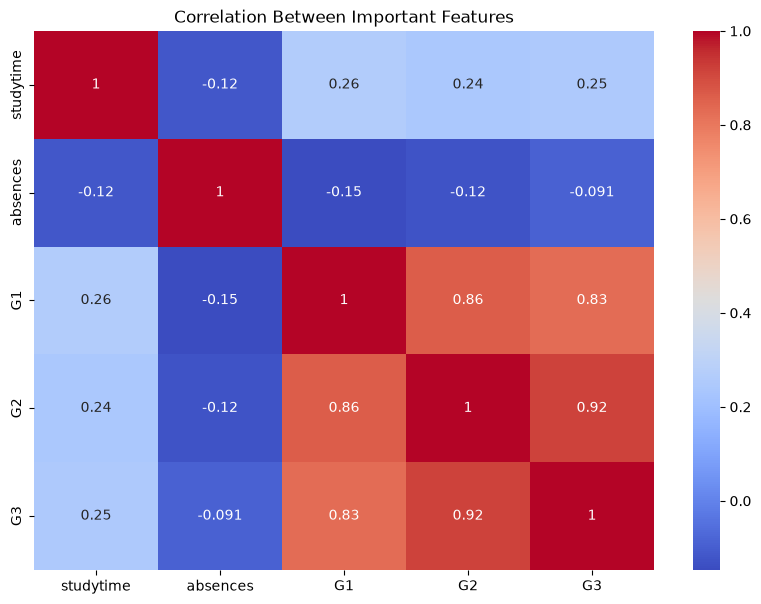

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[["studytime", "absences", "G1", "G2", "G3"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Important Features")
plt.show()

In [12]:
# G1 and G2 represent previous period grades.
# We use them as earlier assessment scores.
features = ["studytime", "absences", "G1", "G2"]

X = df[features]

# Final marks are our regression target
y_reg = df["G3"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.30,
    random_state=42
)

In [14]:
scaler = StandardScaler()

# Fitting scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Applying the same scaling to test data
X_test_scaled = scaler.transform(X_test)

In [15]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_reg = linear_model.predict(X_test_scaled)


In [16]:
#Linear Regression Evaluation
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.3258110051154488
R2 Score: 0.8801054887213487


In [17]:
# In the UCI grading system, 10 or above is considered passing.
# We create a new binary target:
# 1 = Pass
# 0 = Fail
df["Pass"] = (df["G3"] >= 10).astype(int)

print("Pass/Fail counts:")
print(df["Pass"].value_counts())

Pass/Fail counts:
Pass
1    549
0    100
Name: count, dtype: int64


In [18]:
#Features for classification
X = df[features]
y = df["Pass"]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [22]:
decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)


In [23]:
## Logistic Regression Evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Precision:",
      precision_score(y_test, y_pred_logistic))

print("Recall:",
      recall_score(y_test, y_pred_logistic))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.9282051282051282
Precision: 0.9631901840490797
Recall: 0.9515151515151515
Confusion Matrix:
[[ 24   6]
 [  8 157]]


In [24]:
#Descision Tree Evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree))

print("Recall:",
      recall_score(y_test, y_pred_tree))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.9076923076923077
Precision: 0.9681528662420382
Recall: 0.9212121212121213
Confusion Matrix:
[[ 25   5]
 [ 13 152]]
